# Step 4 - The Prophet + XGB hybrid pipeline

This is one of four `step4_model_*` notebooks, one per model architecture. Read them after step 1 (data splitting), step 2 (cross-validation), and step 3 (hyperparameter tuning -- demoed on this very model). Step 3 shows *where* a final set of hyperparameters comes from; here we fit with the package defaults from `params.yaml`. To use the tuned parameters from step 3, pass `config_overrides={"models": {"prophet_xgb": tuning_result.best_params}}` into `run_single_its()`.

**Goal:** walk through `run_single_its()` using the `ProphetXGBHybridModel`.

Sections:
- **4a.** Load the pre-built dummy data.
- **4b.** Fit `ProphetXGBHybridModel` manually and inspect the `FitResult`.
- **4c.** Understand the two-stage fit: Prophet for trend+seasonality, XGB for residuals.
- **4d.** Run the full pipeline via `run_single_its()`.
- **4e.** Inspect `PipelineResult`: metrics, excess table, ATE.
- **4f.** Reproduce the counterfactual plot with annotations.

In [1]:
%matplotlib inline

from IPython.display import display
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")  # suppress Prophet / XGB verbosity
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(name)s - %(message)s",
    datefmt="%H:%M:%S",
)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("its2s").setLevel(logging.WARNING)

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

## 4a. Load the pre-built dummy data

The series has a +8/day intervention effect baked in for 42 days after 2022-03-15.

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset (with +8/day intervention effect)")
print("=" * 60)
print(df.tail())

Dummy dataset (with +8/day intervention effect)
             ds          y  covar_linear  covar_dow  covar_noise
1571 2022-04-21  71.975041      0.995182        3.0    -0.356611
1572 2022-04-22  73.042307      1.033630        4.0     0.247103
1573 2022-04-23  72.275013      1.003513        5.0     1.129482
1574 2022-04-24  69.332534      1.004775        6.0    -0.321536
1575 2022-04-25  69.651058      0.981820        0.0    -1.057655


## 4b. Manual fit

This replicates what `run_single_its` does internally, so we can poke at the `FitResult`.

In [3]:
from its2s.data_prep import prepare_splits
from its2s.models.prophet_xgb import ProphetXGBHybridModel
from its2s.settings import get_model_config, load_config

config = load_config()
splits = prepare_splits(df, INTERVENTION, test_days=TEST_DAYS, holdout_days=HOLDOUT_DAYS)

model_params = get_model_config(config, "prophet_xgb")
model = ProphetXGBHybridModel(params=model_params)

print("Fitting ProphetXGBHybridModel on training data ...")
print(f"  Training rows : {len(splits.train_df)}")
print(f"  Training range: {splits.train_df['ds'].min().date()} -> {splits.train_df['ds'].max().date()}")

fit_result = model.fit(splits.train_df, target_col="y", date_col="ds")

print("\nFitResult fields:")
print(f"  fitted_values  shape = {fit_result.fitted_values.shape}")
print(f"  residuals      shape = {fit_result.residuals.shape}")
print(f"  residuals  mean={fit_result.residuals.mean():.4f}  std={fit_result.residuals.std():.4f}")
print(f"  model_object keys: {list(fit_result.model_object.keys())}")

Fitting ProphetXGBHybridModel on training data ...
  Training rows : 1227
  Training range: 2018-01-01 -> 2021-05-11



FitResult fields:
  fitted_values  shape = (1227,)
  residuals      shape = (1227,)
  residuals  mean=-0.0001  std=1.5196
  model_object keys: ['prophet', 'xgb']


## 4c. Inside the hybrid - Prophet components vs XGB residuals

Stage 1 (Prophet) captures trend + seasonality. Stage 2 (XGB) fits the **residuals** using time features (day_of_week, day_of_year, month, week_of_year). The stage-2 residuals are what drives the Moving Block Bootstrap in step 3.

In [4]:
prophet_model = fit_result.model_object["prophet"]
xgb_model     = fit_result.model_object["xgb"]

prophet_input = splits.train_df[["ds"]].copy()
prophet_input["ds"] = pd.to_datetime(prophet_input["ds"])
prophet_pred = prophet_model.predict(prophet_input)

prophet_yhat     = prophet_pred["yhat"].values
raw_y            = splits.train_df["y"].values
stage1_residuals = raw_y - prophet_yhat     # what XGB was trained on
final_residuals  = fit_result.residuals     # what remained after XGB too

print(f"  Stage-1 residuals (y - Prophet)          std = {stage1_residuals.std():.4f}")
print(f"  Stage-2 residuals (y - Prophet - XGB)    std = {final_residuals.std():.4f}")
print("  -> XGB reduces residual variance from stage 1 to stage 2")

xgb_feat_names = ["day_of_week", "day_of_year", "month", "week_of_year"]
importances = pd.Series(xgb_model.feature_importances_, index=xgb_feat_names).sort_values(ascending=False)
print("\n  XGB feature importances:")
print(importances.to_string())

  Stage-1 residuals (y - Prophet)          std = 1.9591
  Stage-2 residuals (y - Prophet - XGB)    std = 1.5196
  -> XGB reduces residual variance from stage 1 to stage 2

  XGB feature importances:
day_of_year     0.273498
day_of_week     0.251184
week_of_year    0.240247
month           0.235072


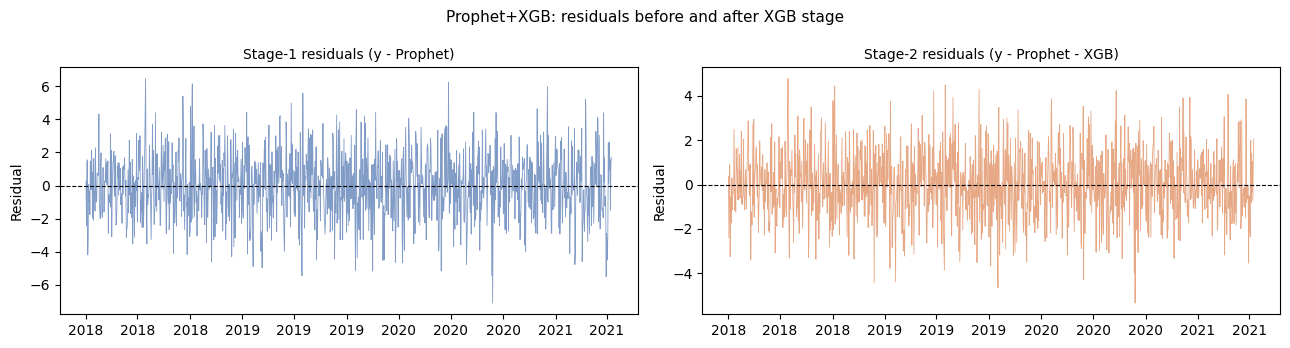

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, resid, title, color in [
    (axes[0], stage1_residuals, "Stage-1 residuals (y - Prophet)", "#4C72B0"),
    (axes[1], final_residuals,  "Stage-2 residuals (y - Prophet - XGB)", "#DD8452"),
]:
    ax.plot(splits.train_df["ds"], resid, linewidth=0.6, color=color, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Residual")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Prophet+XGB: residuals before and after XGB stage", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "step4a_residuals.png", dpi=150)
display(fig)

## 4d. Full pipeline run

MBB bootstrap runs with `n_sim=100` for speed; production use should set this to 1000+.

In [6]:
from its2s import run_single_its

result = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name="prophet_xgb",
    config_overrides={
        "bootstrap": {"n_sim": 100},
        "periods":   {"test_days": TEST_DAYS, "holdout_days": HOLDOUT_DAYS},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print("PipelineResult fields:")
print(f"  model_name       : {result.model_name}")
print(f"  fit_result       : FitResult with {len(result.fit_result.fitted_values)} fitted values")
print(f"  bootstrap_result : BootstrapCIResult  pred_matrix shape = {result.bootstrap_result.pred_matrix.shape}")
print(f"  metrics_train    : {result.metrics_train}")
print(f"  metrics_test     : {result.metrics_test}")

PipelineResult fields:
  model_name       : prophet_xgb
  fit_result       : FitResult with 1227 fitted values
  bootstrap_result : BootstrapCIResult  pred_matrix shape = (349, 100)
  metrics_train    : MetricsResult(rmse=1.519625081661817, mae=1.1978991523480513, mape=2.335012747334822, smape=2.3311317603029615, mase=None, r2=0.957752042733867)
  metrics_test     : MetricsResult(rmse=2.2973971552388655, mae=1.8485015827916151, mape=3.5845107715906335, smape=3.5807528642893223, mase=0.8004196959342977, r2=0.8776018119832437)


## 4e. Metrics and excess table

In [7]:
metrics_df = pd.DataFrame({
    "RMSE":  [result.metrics_train.rmse,  result.metrics_test.rmse],
    "MAE":   [result.metrics_train.mae,   result.metrics_test.mae],
    "MAPE":  [result.metrics_train.mape,  result.metrics_test.mape],
    "SMAPE": [result.metrics_train.smape, result.metrics_test.smape],
    "R2":    [result.metrics_train.r2,    result.metrics_test.r2],
}, index=["Train", "Test"])
print(metrics_df.round(3).to_string())

        RMSE    MAE   MAPE  SMAPE     R2
Train  1.520  1.198  2.335  2.331  0.958
Test   2.297  1.849  3.585  3.581  0.878


In [8]:
print("Period-level excess:")
print(result.excess_table.period_excess.to_string(index=False))
print("\nDaily excess - first 10 holdout days:")
print(result.excess_table.daily_excess.head(10).to_string(index=False))

Period-level excess:
      period start_date   end_date  n_days  total_observed  total_expected  total_excess  excess_ci_lo  excess_ci_hi  excess_pct
Full holdout 2022-03-15 2022-04-25      42     3029.800778     2707.265753    322.535025     302.85572    347.894362   11.913682

Daily excess - first 10 holdout days:
      date  observed  expected  expected_ci_lo  expected_ci_hi    excess  excess_ci_lo  excess_ci_hi  excess_pct  excess_pct_ci_lo  excess_pct_ci_hi
2022-03-15 76.449700 63.194103       62.543612       64.591931 13.255597     11.857770     13.906088   20.976003         18.764044         22.005357
2022-03-16 70.565458 63.058896       62.498015       64.577910  7.506562      5.987549      8.067443   11.904049          9.495169         12.793505
2022-03-17 74.032036 63.480347       62.662132       64.674272 10.551688      9.357764     11.369903   16.621976         14.741198         17.910903
2022-03-18 69.205309 63.901551       62.763032       64.840109  5.303758      4.365200

In [9]:
from its2s.metrics.excess import calc_ate_summary

ate = calc_ate_summary(result.excess_table.daily_excess)
print("Average Treatment Effect (ATE) summary:")
print(ate.to_string(index=False))
print("\n  Total ATE      = sum of daily excess over full holdout")
print("  Mean Daily ATE = average excess per day")
print(f"  Simulated effect was +8/day for {HOLDOUT_DAYS} days -> expected total excess ~{8 * HOLDOUT_DAYS}")

Average Treatment Effect (ATE) summary:
        metric   estimate      ci_lo      ci_hi  n_days
     Total ATE 322.535025 271.663360 371.218861      42
Mean Daily ATE   7.679405   6.468175   8.838544      42

  Total ATE      = sum of daily excess over full holdout
  Mean Daily ATE = average excess per day
  Simulated effect was +8/day for 42 days -> expected total excess ~336


## 4f. Counterfactual plot (annotated)

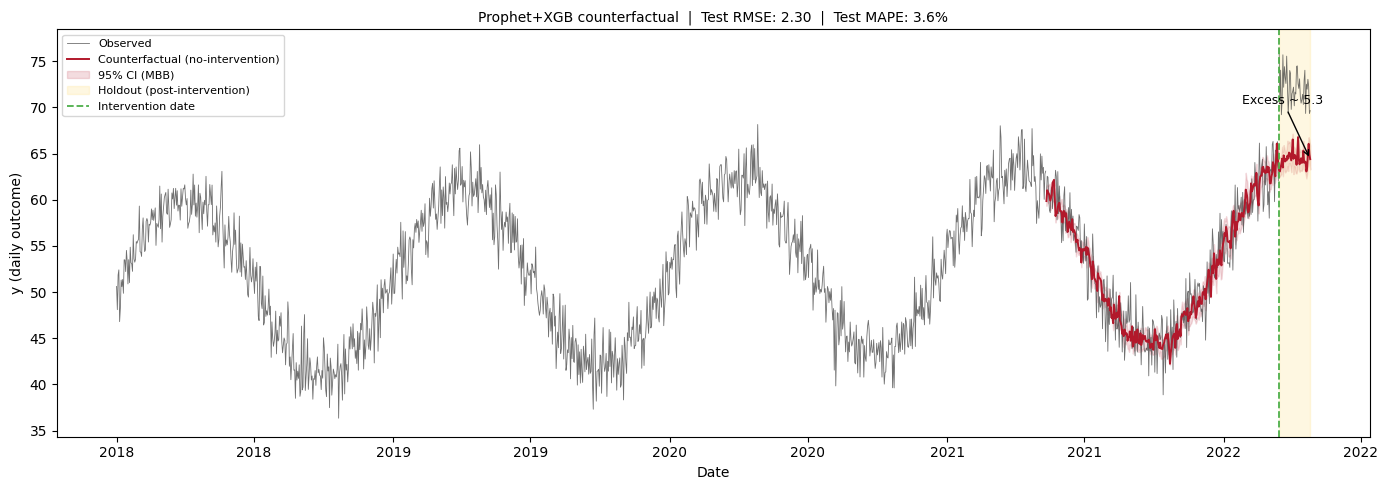

In [10]:
br = result.bootstrap_result
pred_dates = pd.to_datetime(br.dates)
intervention_ts = pd.Timestamp(INTERVENTION)

fig, ax = plt.subplots(figsize=(14, 5))

for part in [splits.train_df, splits.test_df, splits.holdout_df]:
    ax.plot(part["ds"], part["y"], color="#333333", linewidth=0.6, alpha=0.7)
ax.plot([], [], color="#333333", linewidth=0.6, alpha=0.7, label="Observed")

ax.plot(pred_dates, br.predicted, color="#B2182B", linewidth=1.4,
        label="Counterfactual (no-intervention)")
ax.fill_between(pred_dates, br.conf_lo, br.conf_hi,
                color="#B2182B", alpha=0.15, label="95% CI (MBB)")

ax.axvspan(intervention_ts, splits.holdout_df["ds"].max(),
           color="#FEE08B", alpha=0.25, label="Holdout (post-intervention)")
ax.axvline(intervention_ts, color="#4DAF4A", linestyle="--", linewidth=1.3,
           label="Intervention date")

last_date = pred_dates[pred_dates >= intervention_ts][-1]
last_obs  = splits.holdout_df.loc[splits.holdout_df["ds"] == last_date, "y"].values
last_pred = br.predicted[pred_dates == last_date]
if len(last_obs) and len(last_pred):
    ax.annotate(
        f"Excess ~ {float(last_obs[0] - last_pred[0]):.1f}",
        xy=(last_date, float(last_pred[0])),
        xytext=(last_date - pd.Timedelta(days=90), float(last_pred[0]) + 6),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.set_title(
    f"Prophet+XGB counterfactual  |  Test RMSE: {result.metrics_test.rmse:.2f}"
    f"  |  Test MAPE: {result.metrics_test.mape:.1f}%",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "step4a_counterfactual.png", dpi=150)
display(fig)

## Key takeaways

1. `ProphetXGBHybridModel.fit()` runs **two models in sequence**: Prophet for trend+seasonality, then XGB on `y - Prophet_yhat`.
2. The `FitResult.residuals` are the raw material for the Moving Block Bootstrap in step 5.
3. `run_single_its()` orchestrates: `load_config -> prepare_splits -> fit -> bootstrap -> metrics -> excess -> save`.
4. Excess = observed - counterfactual_predicted. With a true +8/day effect over 42 days, total excess should land near 336 (noise aside).